# Clase 14 - Jueves 01 Agosto, 2024

## Gráficos con MatPlotLib y Seaborn

Hoy revisaremos una librería muy utilizada para hacer gráficos `pyplot` dentro de `MatPlotLib`, y `seaborn`. En esta sección revisaremos lo siguientes conceptos:

 - Importación del modulo e introducción
 - Gráficos de barras, histogramas y variantes
 - Gráficos de dispersión (scatterplot) y variantes
 - Boxplot


## Importación del modulo e introducción

En esta sección importaremos el modulo que utilizaremos durante la clase e introduciremos los conceptos básicos para poder empezar a crear nuestros gráficos.

In [ ]:
# Importar el modulo pyplot y llamarlo plt  y seaborn como sns (convención)
import matplotlib.pyplot as plt
import seaborn as sns

Lo primero que debemos generar es una `figura` que será el gráfico y los `ejes` que tendrán los datos asociados al gráfico, lo cual se realiza de la siguiente forma

In [ ]:
fig, ax = plt.subplots()
plt.show()

## Contexto:

En este cuaderno, descubriremos y exploraremos datos del mercado de valores, en particular de algunos valores tecnológicos. Aprenderemos a visualizar diferentes aspectos de la misma utilizando Seaborn y Matplotlib.

* **Date:** Fecha en formato: yy-mm-dd

* **Open:** precio de la acción al abrir el mercado (USD)

* **High:** Precio más alto alcanzado en el día

* **Abj Cierre:** Precio de cierre en el día.

* **Low:** precio más bajo alcanzado en el día

* **Volume:** Volumen de ventas


In [ ]:
import pandas as pd
import numpy as np
Stocks = pd.read_csv('/content/SPfuture.csv', parse_dates = True)

display(Stocks.tail())

In [ ]:
Stocks.info()

#### Limpieza - Base de datos

In [ ]:
# Eliminar todos los NaN de la data, creando una nueva data de comparación
Stocks_v1 = Stocks.dropna()

In [ ]:
# Buscando valores extremos - A priori solo hay un valor sobre 6.000.000
print(Stocks_v1.shape)
Stocks_v1.Volume.describe(percentiles = [0.85, 0.9, 0.95, 0.97, 0.99])

In [ ]:
# Detecctar específicamente cuál es el valor máximo
Stocks_v1.Volume.max()

In [ ]:
# Identificar la fila en la que está contenido ese registro
Stocks_v1[Stocks_v1.Volume == 381207667.0]

# Se observar que de los 302 registros, el dato indexado en la posición 304 es la fila que tiene el registro más alto

In [ ]:
# prompt: elimnar fila de una base datos y corroborar la dimensión de la data

Stocks_v1 = Stocks_v1.drop(Stocks_v1[Stocks_v1.Volume == 381207667.0].index)
print(Stocks_v1.shape)


In [ ]:
# Validar que se haya eliminado correctamente la fila
Stocks_v1.describe(percentiles = [0.8, 0.85, 0.9, 0.95])

In [ ]:
# Visaulizacion decendente de los datos de la variable conflicto
Stocks_v1.Volume.sort_values(ascending = False).head(10)

In [ ]:
# prompt: Observación de la distribución de los datos por medio de un histograma... ahora ya tiene un comportamiento más valido de estudio.
sns.histplot(Stocks_v1['Volume'], kde=True)
plt.show()


In [ ]:
# El conteo de valores ausente en la variable Close
Stocks.Close.isna().sum()

## Luego, graficaremos los precios de cierre de la siguiente forma

In [ ]:
fig, ax = plt.subplots()
ax.plot(Stocks.index,Stocks.Close); # plot(eje x, eje y)

Y ya tenemos nuestro primer gráfico!

Para realizar lo mismo con seaborn, basta especificar un tipo de grafico, en este caso lineas:

In [ ]:
sns.set_theme(style="darkgrid") #nos permite el color de fondo

sns.lineplot(x="Date", y="Close", data=Stocks);

Ahora la idea es ir complicando el tipo de gráfico que queremos pero antes revisaremos algunos comandos básicos que nos serviran más adelante

In [ ]:
# Nombre de los ejes y titulo
fig, ax = plt.subplots()
ax.plot(Stocks.index,Stocks['Close'])
ax.set_xlabel('Tiempo (Días)') # etiqueta eje X
ax.set_ylabel('Precio') # etiqueta eje Y
ax.set_title('SP Future') # Título del gráfico.
plt.show()

Las mismas funciones son aplicables a un gráfico de seaborn

In [ ]:
fig, ax = plt.subplots()
sns.lineplot(x="Date", y="Close", data=Stocks)
ax.set_xlabel('Tiempo (Días)')
ax.set_ylabel('Precio')
ax.set_title('S&P Future')
plt.show()

In [ ]:
# Algunos parámetro del método plot
fig, ax = plt.subplots()
ax.plot(Stocks.index,Stocks['Close'], marker = '+', linestyle = 'dashdot', color = '#140423')
ax.set_xlabel('Tiempo (Días)')
ax.set_ylabel('Precio')
ax.set_title('S&P Future')
plt.show()

# Tipo de lineas - By Dario V.
# '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'

In [ ]:
# ejemplo: Dos variables con los mismos rangos de valores
fig, ax = plt.subplots()
ax.plot(Stocks.index,Stocks['High'], color = 'red')
ax.plot(Stocks.index,Stocks['Low'], color = 'blue')
plt.show()

Supongamos que ahora queremos poner en perspetiva dos series, digamos el precio de cierre y el volumen transado. Si graficamos obtenemos lo siguiente

In [ ]:
# ejemplo extremo: Variables distinto rango
fig, ax = plt.subplots()
ax.plot(Stocks_v1.index,Stocks_v1['Close'], color = 'red')
ax.plot(Stocks_v1.index,Stocks_v1['Volume'], color = 'blue')
plt.show()

Claramente el gráfico anterior no ayuda a comprender ningún tipo de relación que puedan tener estas dos variables dado que al tener una escala de valores tan distinta, una parece una linea constante en 0, para ello tenemos dos alternativas:

In [ ]:
# Generar dos gráficos
fig, ax = plt.subplots(2,1)
ax[0].plot(Stocks_v1.index,Stocks_v1['Close'], color = 'red')
ax[1].plot(Stocks_v1.index,Stocks_v1['Volume'], color = 'blue')
plt.show()

In [ ]:
Stocks['Volume'].max()

In [ ]:
# Ambos gráficos  en la misma ventana, pero con escala propia - Y con la misma variable en el eje X
fig, ax = plt.subplots()
ax.plot(Stocks_v1.index,Stocks_v1['Close'], color = 'red')
ax.set_xlabel('Tiempo (días)')
ax.set_ylabel('Precio')

ax2 = ax.twinx() # En esta parte se solapan los graficos; Dicho de otro modo, se sobre escribe uno sobre el otro.

ax2.plot(Stocks_v1.index,Stocks_v1['Volume'], color = 'blue')
ax2.set_ylabel('Volumen')
plt.show()

In [ ]:
# Lo cual es lo mismo con seaborn
fig, ax = plt.subplots()
sns.lineplot(x="Date", y="Close", data=Stocks_v1, color = 'red')
ax.set_xlabel('Fechas (días)')
ax.set_ylabel('Precio')

ax2 = ax.twinx()

sns.lineplot(x="Date", y="Volume", data=Stocks_v1, color = 'blue')
ax2.set_ylabel('Volumen')
plt.show()

Sitio web que estudia la misma base de datos, en otro periodo de años...
[Link de inspiración](https://www.kaggle.com/code/faressayah/stock-market-analysis-prediction-using-lstm)

# Clase 16 - Lunes Agosto 05, 2024

## Gráficos de barras, histogramas y variantes

Ahora que ya hemos jugado un poco con gráficos, entraremos a ver algunos gráficos super utilizados en data science y estadística como lo son los gráficos de barra e histogramas. Para ilustrar estos gráficos volveremos a los datos antes utilizados sobre animes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Animes = pd.read_csv('/content/anime.csv',delimiter = ';')
Animes.head(1)

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630


In [6]:
# Función groupby
Animes_bar = Animes.groupby('type').agg(['count', 'min'])#['episodes'] # tabla de frecuencia absoluta
Animes_bar

anime_id       name  \
           count  min count   
type                          
Movie       2250    5  2250   
Music        487  731   487   
ONA          604  574   604   
OVA         2176   44  2176   
Special     1646  191  1646   
TV          3568    1  3568   

                                                           genre  \
                                                       min count   
type                                                               
Movie    &quot;Aesop&quot; no Ohanashi yori: Ushi to Ka...  2250   
Music                                        &quot;0&quot;   487   
ONA                                    009 Re:Cyborg x Zip   604   
OVA      &quot;Bungaku Shoujo&quot; Kyou no Oyatsu: Hat...  2176   
Special                   .hack//G.U. Trilogy: Parody Mode  1646   
TV                                            .hack//Roots  3568   

                                                           episodes      \
                                                       min    count min   
type                                                                      
Movie                                               Action     2250   1   
Music    Action, Adventure, Magic, Music, Sci-Fi, Super...      487   1   
ONA                                                 Action      604   1   
OVA                                                 Action     2176   1   
Special                                             Action     1646   1   
TV                                                  Action     3568   2   

        rating       members      
         count   min   count min  
type                              
Movie     2250  2.49    2250  13  
Music      487  3.28     487  24  
ONA        604  2.67     604  25  
OVA       2176  2.00    2176  17  
Special   1646  1.67    1646  24  
TV        3568  3.00    3568  12

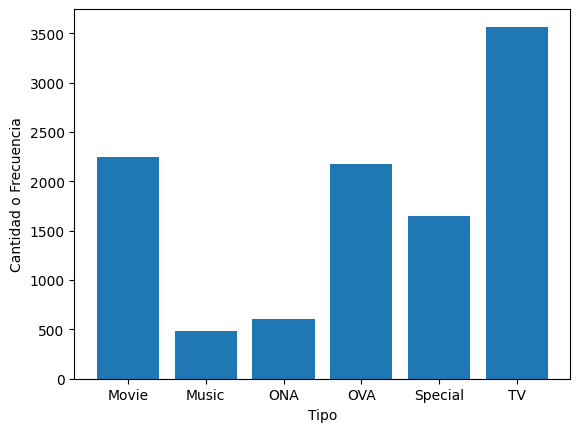

In [7]:
fig, ax = plt.subplots()
Animes_bar = Animes.groupby('type').agg('count')['episodes'] # tabla de frecuencia absoluta
#print(Animes_bar)
ax.bar(Animes_bar.index, Animes_bar)
ax.set_xlabel('Tipo')
ax.set_ylabel('Cantidad o Frecuencia')
plt.show();

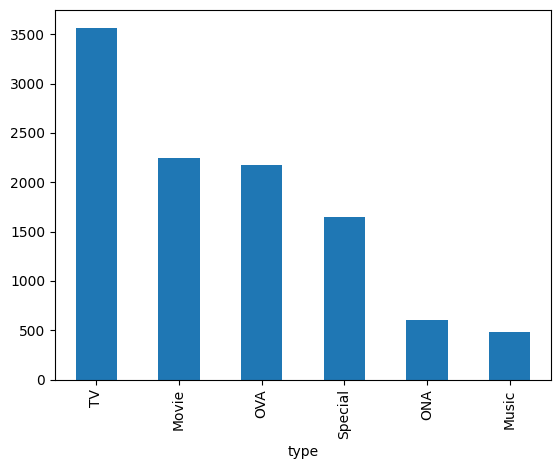

In [9]:
#podemos graficar lo mismo directamente a través de la función .plot de pandas
Animes.type.value_counts().plot(kind='bar');

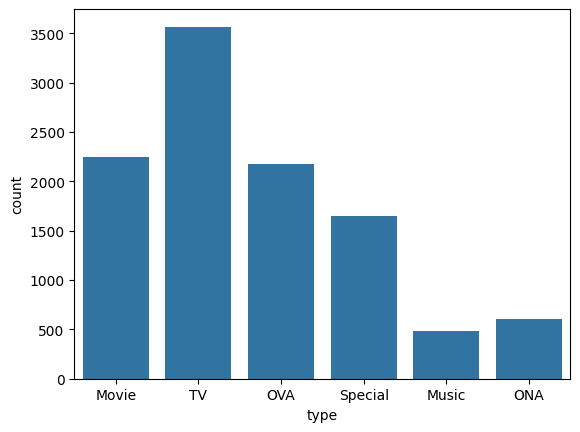

In [10]:
#O aún más fácil, con seaborn
sns.countplot(x='type', data=Animes);

Ya tenemos nuestro gráfico de barras. Ahora si tenemos una variable de la cual estamos en conocer su distribución, entonces necesitaremos hacer un histograma. Utilizando los mismos datos ilustraremos como se realiza

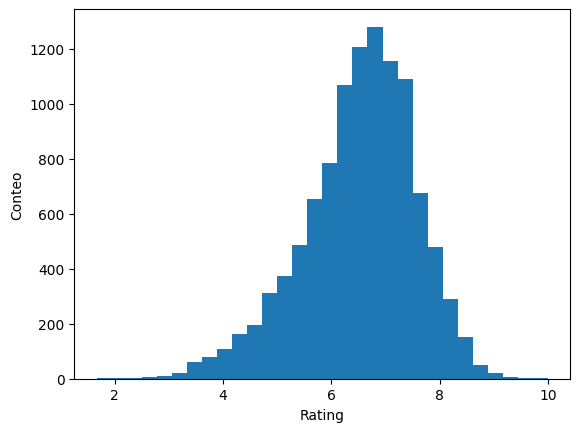

In [15]:
fig, ax = plt.subplots()
ax.hist(Animes['rating'], bins = 30) #density, cumulative
ax.set_xlabel('Rating')
ax.set_ylabel('Conteo')
plt.show()

Algo interesante de Seaborn es que nos permite ver el suavizado de la función de distribución de manera rápida

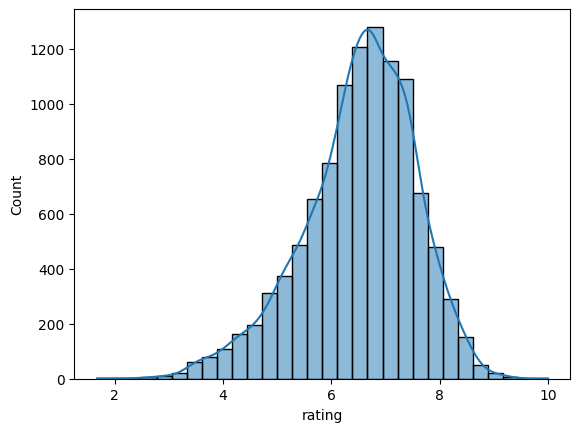

In [16]:
sns.histplot(data=Animes, x="rating", bins = 30, kde=True);

Supongamos que tenemos otra variable que correponde a otro estilo de ranking (la cual crearemos a continuación) y queremos comprar sus distribuciones, entonces lo hacemos de la siguiente manera

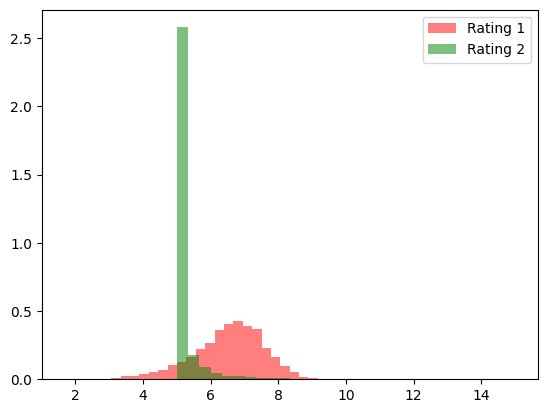

In [17]:
Animes['rating2'] = Animes['members']*10/Animes['members'].max()+5
fig, ax = plt.subplots()
ax.hist(Animes['rating'],bins = 30, density = True, color = 'red',alpha = 0.5, label = 'Rating 1')
ax.hist(Animes['rating2'], bins = 30, density = True, color = 'green', alpha = 0.5, label = 'Rating 2')
ax.legend(loc = 'upper right')
plt.show()

In [18]:
Animes['rating2'].describe(percentiles = [.2, 0.8, 0.85,0.95, 0.99])

count    10731.000000
mean         5.198543
std          0.570890
min          5.000118
20%          5.001341
50%          5.014804
80%          5.185410
85%          5.299536
95%          6.005146
99%          7.907871
max         15.000000
Name: rating2, dtype: float64

Por otro lado, con seaborn podemos ver rápidamente un histograma para cada rating, desagregado por variables categóricas, como lo es type

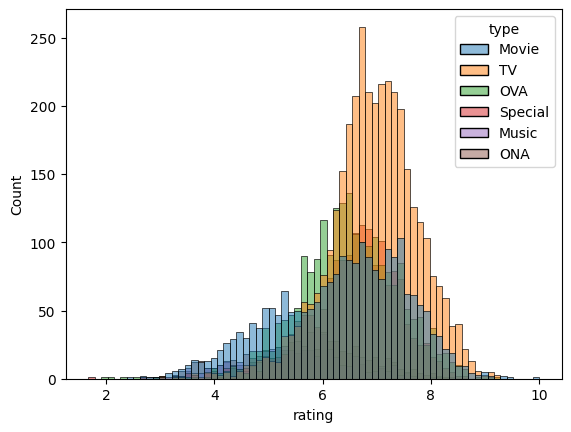

In [19]:
sns.histplot(data=Animes, x="rating", hue="type");

Finalmente, el último gráfico de barras que revisaremos es uno conocido como stacked bar, que es útil para graficar las proporciones de ciertos atributos o caracteristicas para grupos de variables. Por ejemplo, crearemos un dataset que consiste en cantidad de niños, adolecentes, adultos y ancianos en cuatro países de latinoamerica Chile, Argentina, Ecuador y Colombia. Los datos son los siguientes:

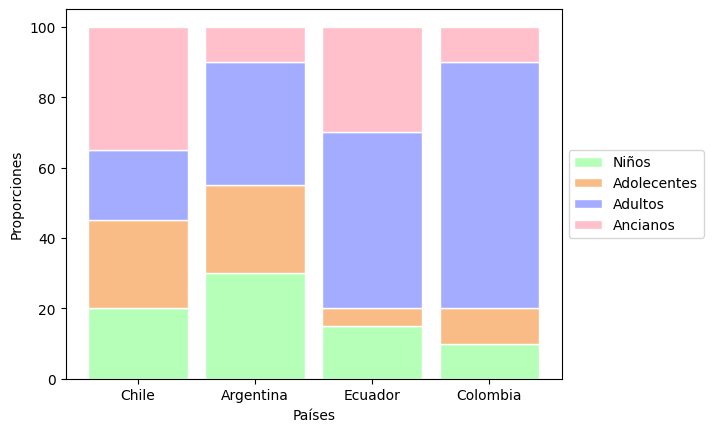

In [20]:
# Data
r = [0,1,2,3]
raw_data = {'Niños': [20, 30, 15, 10],
            'Adolecentes': [25, 25, 5, 10],
            'Adultos': [20, 35, 50, 70],
            'Ancianos': [35, 10, 30, 10]}
names = ['Chile','Argentina','Ecuador','Colombia']
df = pd.DataFrame(raw_data, index=names)

fig, ax = plt.subplots()
ax.bar(df.index, df['Niños'], label='Niños', color='#b5ffb9', edgecolor='white', width=0.85)
ax.bar(df.index, df['Adolecentes'], bottom=df['Niños'], color='#f9bc86', label='Adolecentes', edgecolor='white', width=0.85)
ax.bar(df.index, df['Adultos'], bottom=df['Niños'] + df['Adolecentes'], color='#a3acff', edgecolor='white', width=0.85, label='Adultos')
ax.bar(df.index, df['Ancianos'], bottom=df['Niños'] + df['Adolecentes'] + df['Adultos'], color='pink', edgecolor='white', width=0.85, label='Ancianos')
ax.set_xlabel('Países')
ax.set_ylabel('Proporciones')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

Sin tanto control pero más rápido:

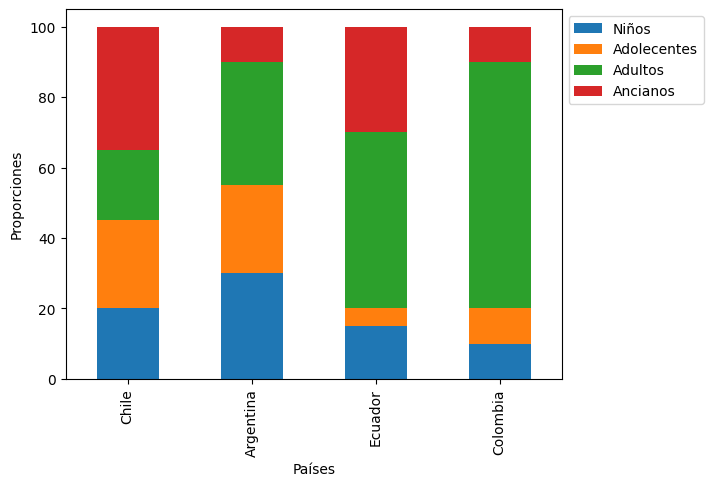

In [21]:
ax = df.reset_index().plot(x='index', kind='bar', stacked=True)
ax.set_xlabel("Países")
ax.set_ylabel("Proporciones")
plt.legend(bbox_to_anchor=(1.0, 1.0))
plt.show()

## Gráficos de dispersión

Los gráficos de dispersión o scatterplot son muy útiles para descubrir relaciones entre variables o si estas presentan algún tipo de agrupamiento, entre otros. A continuación ilustraremos como construir dicho gráfico y algunas variantes. Partiremos utilizando los datos de Anime

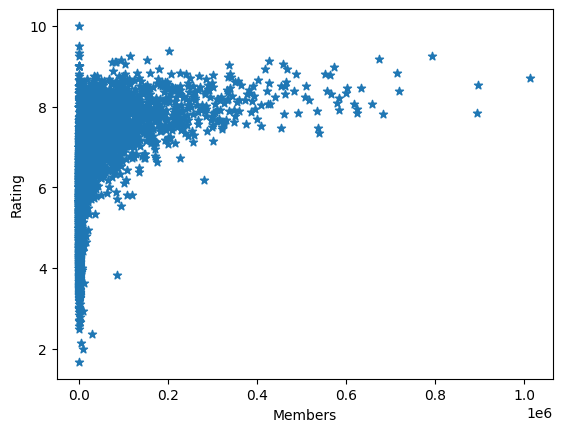

In [22]:
fig, ax = plt.subplots()
# Primero graficaremos el rating versus la cantidad de miembros
ax.scatter(Animes['members'],Animes['rating'], marker = '*')
ax.set_xlabel('Members')
ax.set_ylabel('Rating')
plt.show()

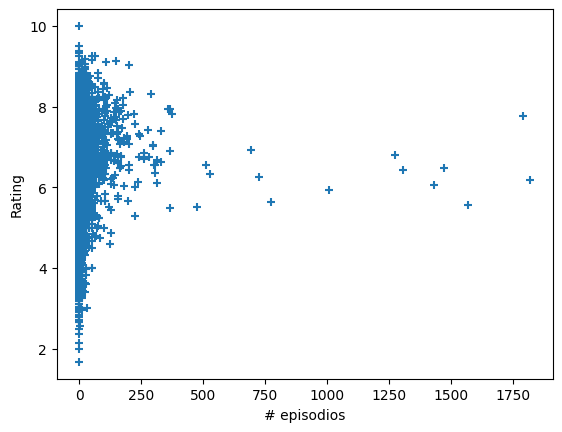

In [23]:
# Ahora rating versus cantidad de capítulos
fig, ax = plt.subplots()
ax.scatter(Animes['episodes'],Animes['rating'],marker = '+')
ax.set_ylabel('Rating')
ax.set_xlabel('# episodios')
plt.show()

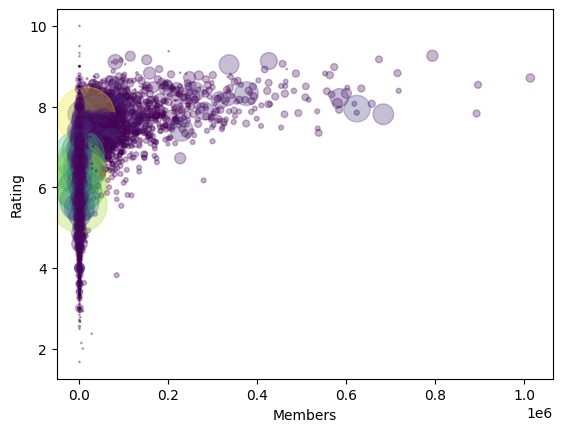

In [24]:
# Ahora podemos hacer algo un poco más sofisticado, haciendo un gráfico rating vs miembros, donde el tamaño
# del punto sea dado por episodes
fig, ax = plt.subplots()
ax.scatter(Animes['members'],Animes['rating'], c = Animes['episodes'], s = Animes['episodes'], alpha = 0.3)
ax.set_xlabel('Members')
ax.set_ylabel('Rating')
plt.show()

Al igual que antes, seaborn es similar, pero permite desagregar las imagenes por categoría de manera rápida

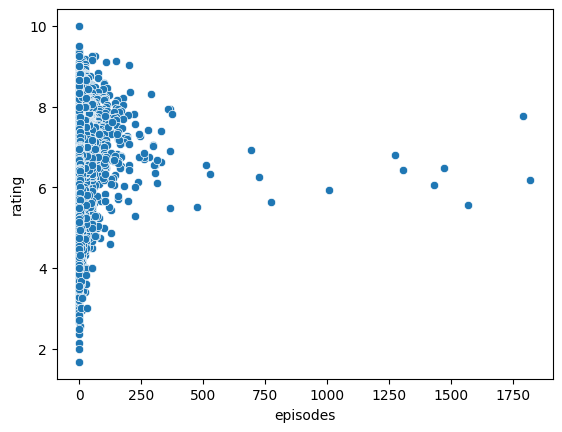

In [25]:
sns.scatterplot(data=Animes, x="episodes", y="rating");

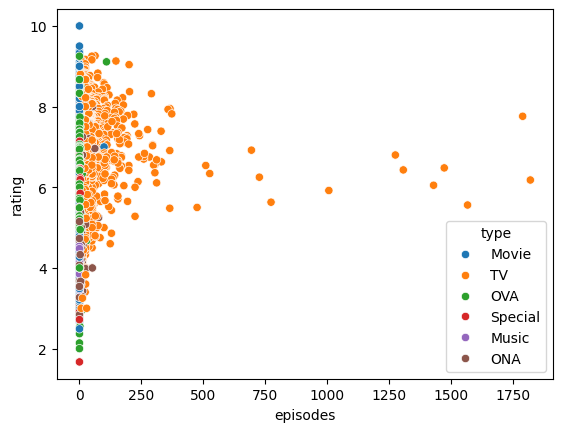

In [26]:
sns.scatterplot(data=Animes, x="episodes", y="rating", hue="type");

Así, podemos observar rápidamente, que son los programas de TV los que tienen más episodios, independiente del rating. Lo cual nos permite evadir el caer en un error de correlación

## Boxplot

El diagrama de caja o boxplot es un gráfico muy utilizado con distintos propositos, dado que el muestra de manera gráfica y utilizando indicadores de posición, la distribución y dispersión de una variable.

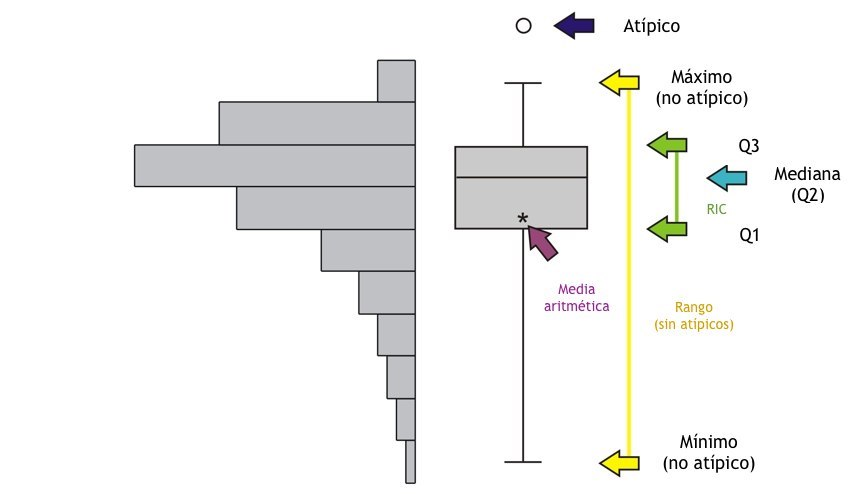

 A continuación mostraremos como graficar un boxplot así como también algunas variantes cuando son varias variables.

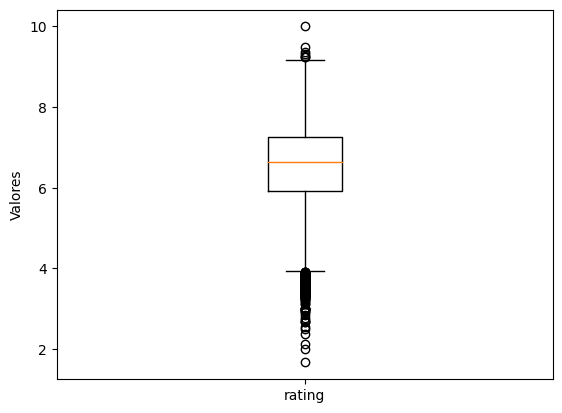

In [27]:
fig, ax = plt.subplots()
ax.boxplot(Animes['rating'], labels = ['rating']) # showfliers = False, vert = False
ax.set_ylabel('Valores')
plt.show()

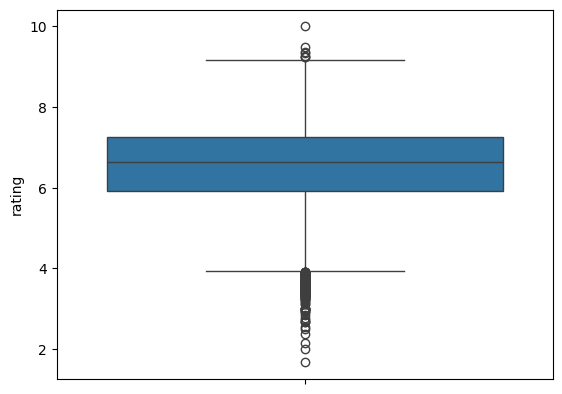

In [28]:
sns.boxplot(y="rating", data=Animes);

Con seaborn podemos rápidamente ver 2 dimensiones:

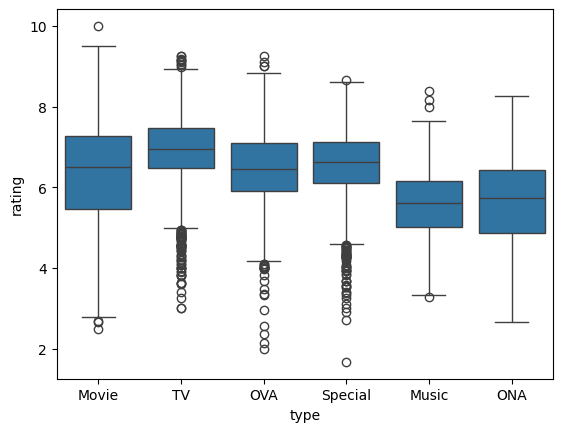

In [29]:
sns.boxplot(x="type", y="rating", data=Animes);

Si agregamos una categoría extra como que tan largo son los animés, podremos ver incluso una tercera dimensión

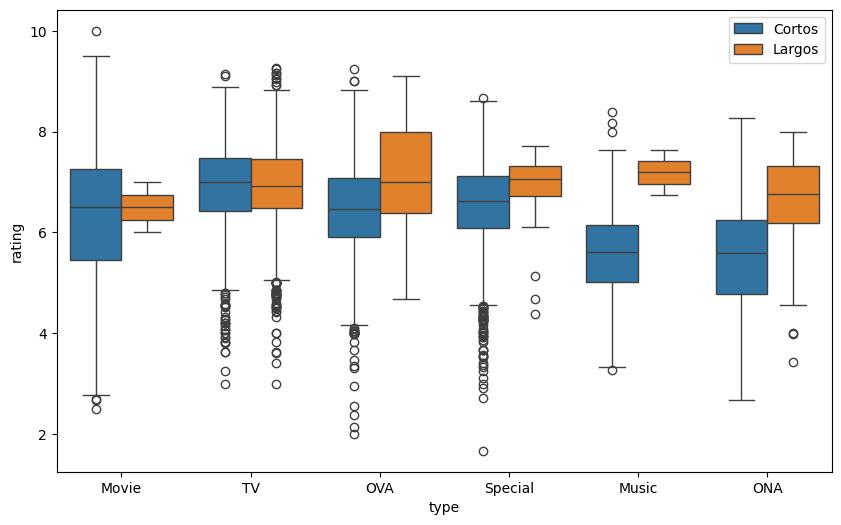

In [30]:
Animes['duracion'] = np.where(Animes.episodes>np.mean(Animes.episodes),'Largos','Cortos')

# Esto es para el tamaño#
fig_dims = (10, 6)
fig, ax = plt.subplots(figsize=fig_dims)
#########################

sns.boxplot(x="type", y="rating", hue='duracion', data=Animes);
plt.legend(bbox_to_anchor=(1.0, 1.0));